In [ ]:
!pip install tensorflow
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 591.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 19.6 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import ipywidgets as widgets
import io
from PIL import Image
from IPython.display import display, clear_output
from warnings import filterwarnings

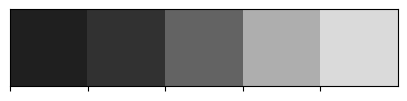

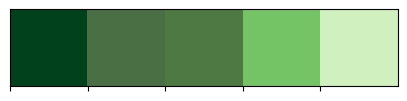

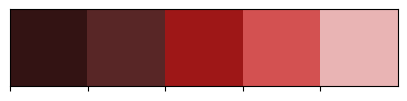

In [ ]:
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_red = ["#331313", "#582626", '#9E1717', '#D35151', '#E9B4B4']
colors_green = ['#01411C','#4B6F44','#4F7942','#74C365','#D0F0C0']

sns.palplot(colors_dark)
sns.palplot(colors_green)
sns.palplot(colors_red)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

In [ ]:
X_train = []
y_train = []
image_size = 150
for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/diff_tumor dataset','Training',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/drive/MyDrive/diff_tumor dataset','Testing',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        y_train.append(i)

X_train = np.array(X_train)
y_train = np.array(y_train)

100%|██████████| 74/74 [00:16<00:00,  4.49it/s]


In [ ]:
X_train, y_train = shuffle(X_train,y_train, random_state=101)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.1,random_state=101)

In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)


y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)


In [ ]:
y_test

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [ ]:
effnet = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(image_size, image_size, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = effnet.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(rate=0.5)(model)
model = tf.keras.layers.Dense(4,activation='softmax')(model)
model = tf.keras.models.Model(inputs=effnet.input, outputs = model)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 150, 150, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 150, 150, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 150, 150, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 150, 150, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 151, 151, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 75, 75, 32)     │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 75, 75, 32)     │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 75, 75, 32)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 75, 75, 32)     │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 75, 75, 32)     │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 75, 75, 32)     │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 4,012,672 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tensorboard = TensorBoard(log_dir='logs')

# 2. ModelCheckpoint to save the best model (based on validation accuracy)
checkpoint = ModelCheckpoint(
    "effnet.h5",               # File name to save
    monitor="val_accuracy",   # Metric to watch
    save_best_only=True,      # Only save best version
    mode="auto",
    verbose=1
)

# 3. ReduceLROnPlateau to lower LR if val_accuracy stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.3,
    patience=2,
    min_delta=0.001,
    mode='auto',
    verbose=1
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=12,
    verbose=1,
    batch_size=32,
    callbacks=[tensorboard, checkpoint, reduce_lr]
)

Epoch 1/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7343 - loss: 0.6606
Epoch 1: val_accuracy improved from -inf to 0.72789, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 638s 7s/step - accuracy: 0.7355 - loss: 0.6581 - val_accuracy: 0.7279 - val_loss: 1.2346 - learning_rate: 0.0010
Epoch 2/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9437 - loss: 0.1759
Epoch 2: val_accuracy improved from 0.72789 to 0.89796, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 580s 7s/step - accuracy: 0.9437 - loss: 0.1760 - val_accuracy: 0.8980 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 3/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9631 - loss: 0.1244
Epoch 3: val_accuracy did not improve from 0.89796
83/83 ━━━━━━━━━━━━━━━━━━━━ 565s 7s/step - accuracy: 0.9630 - loss: 0.1247 - val_accuracy: 0.8844 - val_loss: 0.3666 - learning_rate: 0.0010
Epoch 4/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9753 - loss: 0.0740
Epoch 4: val_accuracy improved from 0.89796 to 0.94558, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 556s 7s/step - accuracy: 0.9753 - loss: 0.0741 - val_accuracy: 0.9456 - val_loss: 0.2164 - learning_rate: 0.0010
Epoch 5/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9754 - loss: 0.0771
Epoch 5: val_accuracy did not improve from 0.94558
83/83 ━━━━━━━━━━━━━━━━━━━━ 555s 7s/step - accuracy: 0.9753 - loss: 0.0774 - val_accuracy: 0.9116 - val_loss: 0.2616 - learning_rate: 0.0010
Epoch 6/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9821 - loss: 0.0606
Epoch 6: val_accuracy did not improve from 0.94558

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
83/83 ━━━━━━━━━━━━━━━━━━━━ 560s 7s/step - accuracy: 0.9820 - loss: 0.0606 - val_accuracy: 0.9286 - val_loss: 0.1655 - learning_rate: 0.0010
Epoch 7/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9896 - loss: 0.0316
Epoch 7: val_accuracy improved from 0.94558 to 0.96259, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 563s 7s/step - accuracy: 0.9896 - loss: 0.0316 - val_accuracy: 0.9626 - val_loss: 0.0755 - learning_rate: 3.0000e-04
Epoch 8/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9959 - loss: 0.0128
Epoch 8: val_accuracy improved from 0.96259 to 0.96939, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 556s 7s/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 0.9694 - val_loss: 0.0795 - learning_rate: 3.0000e-04
Epoch 9/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9977 - loss: 0.0095
Epoch 9: val_accuracy improved from 0.96939 to 0.97279, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 559s 7s/step - accuracy: 0.9977 - loss: 0.0095 - val_accuracy: 0.9728 - val_loss: 0.0761 - learning_rate: 3.0000e-04
Epoch 10/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9978 - loss: 0.0094
Epoch 10: val_accuracy improved from 0.97279 to 0.97619, saving model to effnet.h5


83/83 ━━━━━━━━━━━━━━━━━━━━ 558s 7s/step - accuracy: 0.9978 - loss: 0.0094 - val_accuracy: 0.9762 - val_loss: 0.0563 - learning_rate: 3.0000e-04
Epoch 11/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9985 - loss: 0.0075
Epoch 11: val_accuracy did not improve from 0.97619
83/83 ━━━━━━━━━━━━━━━━━━━━ 555s 7s/step - accuracy: 0.9985 - loss: 0.0075 - val_accuracy: 0.9762 - val_loss: 0.0674 - learning_rate: 3.0000e-04
Epoch 12/12
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9961 - loss: 0.0124
Epoch 12: val_accuracy did not improve from 0.97619

Epoch 12: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
83/83 ━━━━━━━━━━━━━━━━━━━━ 552s 7s/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.9660 - val_loss: 0.0701 - learning_rate: 3.0000e-04


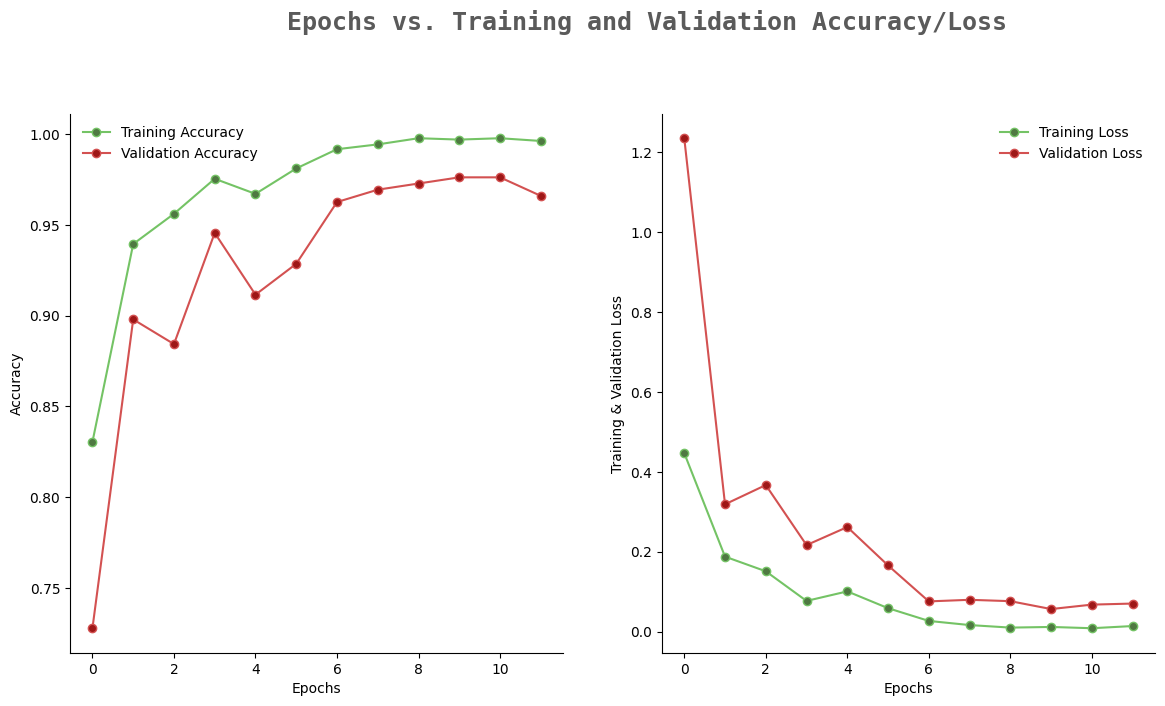

In [ ]:
filterwarnings('ignore')

epochs = [i for i in range(12)]
fig, ax = plt.subplots(1,2,figsize=(14,7))
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.text(s='Epochs vs. Training and Validation Accuracy/Loss',size=18,fontweight='bold',
             fontname='monospace',color=colors_dark[1],y=1,x=0.28,alpha=0.8)

sns.despine()
ax[0].plot(epochs, train_acc, marker='o',markerfacecolor=colors_green[2],color=colors_green[3],
           label = 'Training Accuracy')
ax[0].plot(epochs, val_acc, marker='o',markerfacecolor=colors_red[2],color=colors_red[3],
           label = 'Validation Accuracy')
ax[0].legend(frameon=False)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

sns.despine()
ax[1].plot(epochs, train_loss, marker='o',markerfacecolor=colors_green[2],color=colors_green[3],
           label ='Training Loss')
ax[1].plot(epochs, val_loss, marker='o',markerfacecolor=colors_red[2],color=colors_red[3],
           label = 'Validation Loss')
ax[1].legend(frameon=False)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Training & Validation Loss')

fig.show()

In [ ]:
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)
print(classification_report(y_test_new,pred))

11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        93
           1       0.91      1.00      0.95        51
           2       0.97      0.96      0.96        96
           3       1.00      0.98      0.99        87

    accuracy                           0.97       327
   macro avg       0.96      0.97      0.97       327
weighted avg       0.97      0.97      0.97       327



In [ ]:
tf.saved_model.save(model, 'brain_tumor_model')

In [ ]:
!pip install tensorflowjs
!tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model /content/brain_tumor_model /content/model/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 102.0 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
2025-04-07 13:36:19.459155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744032979.480006   42947 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744032979.486193   42947 cuda_blas.cc:1407] Unabl

In [ ]:
!zip -r tfjs_model.zip model/


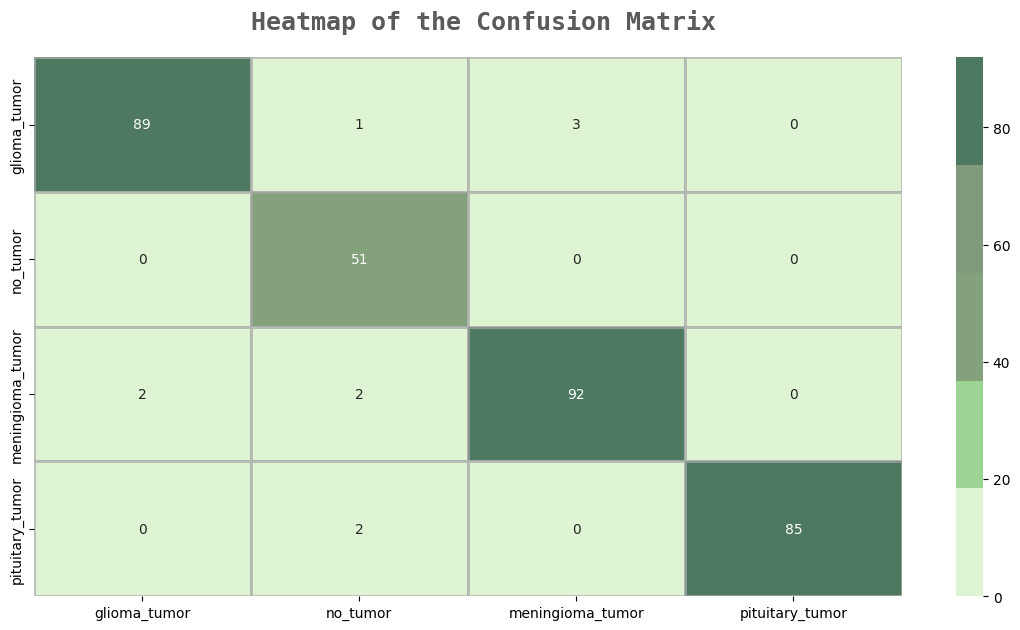

In [ ]:
fig,ax=plt.subplots(1,1,figsize=(14,7))
sns.heatmap(confusion_matrix(y_test_new,pred),ax=ax,xticklabels=labels,yticklabels=labels,annot=True,
           cmap=colors_green[::-1],alpha=0.7,linewidths=2,linecolor=colors_dark[3])
fig.text(s='Heatmap of the Confusion Matrix',size=18,fontweight='bold',
             fontname='monospace',color=colors_dark[1],y=0.92,x=0.28,alpha=0.8)

plt.show()

In [ ]:
# Set image path and size
image_path = '/content/drive/MyDrive/diff_tumor dataset/Training/meningioma_tumor/m (30).jpg'
image_size = 150

# Preprocess just like training
img = cv2.imread(image_path)
img = cv2.resize(img, (image_size, image_size))
img = img.reshape(1, image_size, image_size, 3)

# Predict
pred = model.predict(img)
class_index = np.argmax(pred, axis=1)[0]

# Optional: Map index to label
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']  # your class order here
predicted_label = labels[class_index]

print(f"Predicted class: {predicted_label}")

In [ ]:
# Set image path and size
image_path = '/content/drive/MyDrive/diff_tumor dataset/Testing/pituitary_tumor/image(10).jpg'
image_size = 150

# Preprocess just like training
img = cv2.imread(image_path)
img = cv2.resize(img, (image_size, image_size))
img = img.reshape(1, image_size, image_size, 3)

# Predict
pred = model.predict(img)
class_index = np.argmax(pred, axis=1)[0]

# Optional: Map index to label
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']  # your class order here
predicted_label = labels[class_index]

print(f"Predicted class: {predicted_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted class: pituitary_tumor


In [ ]:
!tensorflowjs_converter \
    --input_format keras \
    /content/effnet.h5 \
    /content/model2/


2025-04-07 13:47:20.555059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744033640.576031   47879 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744033640.582304   47879 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744033640.599064   47879 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744033640.599089   47879 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744033640.599092   47879 computation_placer.cc:177] computation placer alr

In [ ]:
!zip -r tfjs_model2.zip model2/

  adding: model2/ (stored 0%)
  adding: model2/group1-shard3of4.bin (deflated 7%)
  adding: model2/group1-shard1of4.bin (deflated 7%)
  adding: model2/group1-shard2of4.bin (deflated 7%)
  adding: model2/model.json (deflated 97%)
  adding: model2/group1-shard4of4.bin (deflated 7%)
